# BTHSA PM2.5 Deweathering and SHAP

This notebook reproduces the Dai/Hou-style annual deweathering and SHAP analysis on the repository-local BTHSA panel. The first-pass target is historical alignment, not the 2025 Spring Festival counterfactual case.

## Experiment Contract

- Data: `data/dataset_bthsa_yrd_aqi_mete_emis.nc` plus `data/stations_bthsa.csv`.
- Scope: 228 BTHSA stations aggregated to 28 city-level hourly series by city mean.
- Target: city-level hourly `PM2.5`.
- Model: `sklearn.ensemble.RandomForestRegressor`.
- SHAP: `shap.TreeExplainer` on the final all-year city models.
- Split for diagnostic performance: train `2016-2021`, validation `2022`, test `2023`.
- Outputs: reusable CSV/NPZ caches under `exp/cache/bthsa_pm25_deweather_shap/` and figures under `fig/bthsa_pm25_deweather_shap/`.

In [12]:
from pathlib import Path
import importlib
import subprocess
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "data" / "dataset_bthsa_yrd_aqi_mete_emis.nc").exists():
    ROOT = ROOT.parent

print(f"Kernel Python: {sys.executable}")
print(sys.version)

try:
    shap = importlib.import_module("shap")
except ImportError:
    print("SHAP is missing in this kernel. Installing into the active kernel environment...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "shap==0.44.1",
        "numpy<2",
        "pandas<3",
        "scikit-learn<1.4",
        "scipy<1.12",
        "numba<0.60",
    ])
    importlib.invalidate_caches()
    shap = importlib.import_module("shap")

print(f"SHAP: {shap.__version__}")
ROOT


Kernel Python: /opt/anaconda3/bin/python
3.11.8 | packaged by conda-forge | (main, Feb 16 2024, 20:49:36) [Clang 16.0.6 ]
SHAP: 0.44.1


PosixPath('/Users/yangmingzhe/Desktop/code/github/EISyn')

In [13]:
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
from scripts import bthsa_pm25_deweather_shap as exp

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

## Run Settings

Keep `RUN_SMOKE = True` for quick validation. Set it to `False` for the full 28-city, 2016-2023 run. The full run trains one Random Forest per city and computes sampled SHAP values, so it can take a while.

In [14]:
RUN_SMOKE = False

config = exp.build_config(root_dir=ROOT, smoke=RUN_SMOKE)
config

ExperimentConfig(root_dir=PosixPath('/Users/yangmingzhe/Desktop/code/github/EISyn'), dataset_path=PosixPath('data/dataset_bthsa_yrd_aqi_mete_emis.nc'), station_path=PosixPath('data/stations_bthsa.csv'), cache_dir=PosixPath('exp/cache/bthsa_pm25_deweather_shap'), fig_dir=PosixPath('fig/bthsa_pm25_deweather_shap'), random_state=0, n_estimators=200, min_samples_leaf=5, n_jobs=-1, shap_sample_per_city=5000, deweather_samples=1000, smoke=False, smoke_cities=('beijing', 'tianjin'), smoke_hours_per_city=2000)

## Execute Pipeline

The helper writes all reusable artifacts as it runs: city feature table, model metrics, deweathered PM2.5, SHAP samples, SHAP global importance, and figures.

In [15]:
result = exp.run_experiment(config)

features = result["features"]
metrics = result["metrics"]
deweathered = result["deweathered"]
importance = result["importance"]
plot_paths = result["plot_paths"]

features.shape, metrics.shape, deweathered.shape, importance.shape, len(plot_paths)

((1962912, 33), (84, 6), (1962912, 7), (756, 5), 11)

## Data Sanity Checks

In [16]:
display(features.head())
print("cities", features["city_en"].nunique())
print("rows", len(features))
print("unique city-time rows", not features.duplicated(["time", "city_en"]).any())
print("splits")
display(features.groupby("split").size())

,time,city_en,city,station_count,PM2.5,O3,temp_c,dewpoint_c,RH,WS,WD_sin,WD_cos,sp,tp,blh,msdwswrf,delta_temp_24h,meic_PM25,meic_PM10,meic_NOx,meic_SO2,meic_VOC,meic_NH3,year,dayofyear_sin,dayofyear_cos,hour_sin,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos,split
0,2016-01-02 00:00:00,anyang,安阳市,6,234.166672,12.833333,-1.664496,-3.854926,84.999842,0.784209,0.978736,-0.205125,100450.937500,-1.734723e-18,15.434812,5.907656,-3.349640,0.213449,0.256925,0.541670,0.164346,0.621888,0.367753,2016.0,0.034328,0.999411,0.000000,1.000000,-0.974928,-0.222521,0.5,0.866025,train
1,2016-01-02 01:00:00,anyang,安阳市,6,310.166656,12.833333,-1.503271,-3.852057,84.016942,1.145721,0.368291,-0.929711,100471.375000,-1.734723e-18,31.487036,106.999855,-3.023804,0.228174,0.274135,0.552582,0.173519,0.650772,0.369441,2016.0,0.034328,0.999411,0.258819,0.965926,-0.974928,-0.222521,0.5,0.866025,train
2,2016-01-02 02:00:00,anyang,安阳市,6,375.166656,12.000000,5.092279,-1.421027,62.790566,1.304353,0.019937,-0.999801,100485.867188,-1.734723e-18,84.839027,262.956146,-0.143799,0.229044,0.274707,0.534917,0.172239,0.642144,0.369465,2016.0,0.034328,0.999411,0.500000,0.866025,-0.974928,-0.222521,0.5,0.866025,train
3,2016-01-02 03:00:00,anyang,安阳市,6,393.000000,13.166667,5.895959,-1.192450,60.390196,0.483158,-0.891143,-0.453722,100458.179688,-1.734723e-18,163.368362,397.297119,0.699188,0.230278,0.275988,0.498035,0.171967,0.627677,0.369632,2016.0,0.034328,0.999411,0.707107,0.707107,-0.974928,-0.222521,0.5,0.866025,train
4,2016-01-02 04:00:00,anyang,安阳市,6,414.000000,15.833333,6.939661,-0.738196,58.101300,0.812347,-0.920864,0.389883,100394.281250,-1.734723e-18,248.658279,483.423706,0.910095,0.231677,0.276527,0.476789,0.168630,0.614550,0.369569,2016.0,0.034328,0.999411,0.866025,0.500000,-0.974928,-0.222521,0.5,0.866025,train


cities 28
rows 1962912
unique city-time rows True
splits


split
test      245280
train    1472352
val       245280
dtype: int64

## Model Diagnostics

In [17]:
metrics.sort_values(["split", "rmse"]).head(20)

,rmse,mae,corr,city_en,split,n_samples
17,23.526407,15.661459,0.648050,changzhi,test,8760
77,23.929739,15.737812,0.650798,yangquan,test,8760
8,24.536064,15.031750,0.724339,beijing,test,8760
41,25.218037,16.398360,0.643143,jincheng,test,8760
38,25.940664,17.123396,0.710687,jinan,test,8760
83,26.487635,18.264409,0.742612,zibo,test,8760
35,28.821877,18.587720,0.667970,jiaozuo,test,8760
65,29.462133,18.801362,0.668429,tangshan,test,8760
62,29.463150,18.806360,0.624289,taiyuan,test,8760
68,29.616425,18.279056,0.723361,tianjin,test,8760


In [18]:
test_metrics = metrics[metrics["split"] == "test"].sort_values("rmse")
display(test_metrics)
print("mean test RMSE", test_metrics["rmse"].mean())
print("mean test corr", test_metrics["corr"].mean())

,rmse,mae,corr,city_en,split,n_samples
17,23.526407,15.661459,0.648050,changzhi,test,8760
77,23.929739,15.737812,0.650798,yangquan,test,8760
8,24.536064,15.031750,0.724339,beijing,test,8760
41,25.218037,16.398360,0.643143,jincheng,test,8760
38,25.940664,17.123396,0.710687,jinan,test,8760
83,26.487635,18.264409,0.742612,zibo,test,8760
35,28.821877,18.587720,0.667970,jiaozuo,test,8760
65,29.462133,18.801362,0.668429,tangshan,test,8760
62,29.463150,18.806360,0.624289,taiyuan,test,8760
68,29.616425,18.279056,0.723361,tianjin,test,8760


mean test RMSE 30.61682656016193
mean test corr 0.6676426586812504


## Deweathered PM2.5 Output

In [19]:
display(deweathered.head())
regional = deweathered.groupby("time", as_index=False)[["PM2.5_obs", "PM2.5_deweathered", "meteo_component"]].mean()
display(regional.head())

,time,city_en,city,split,PM2.5_obs,PM2.5_deweathered,meteo_component
0,2016-01-02 00:00:00,anyang,安阳市,train,234.166672,244.350582,-10.183910
1,2016-01-02 01:00:00,anyang,安阳市,train,310.166656,245.982265,64.184392
2,2016-01-02 02:00:00,anyang,安阳市,train,375.166656,248.796530,126.370127
3,2016-01-02 03:00:00,anyang,安阳市,train,393.000000,248.016255,144.983745
4,2016-01-02 04:00:00,anyang,安阳市,train,414.000000,252.424499,161.575501


,time,PM2.5_obs,PM2.5_deweathered,meteo_component
0,2016-01-02 00:00:00,216.836670,226.010706,-9.174032
1,2016-01-02 01:00:00,225.315948,225.776277,-0.460315
2,2016-01-02 02:00:00,246.868195,223.076377,23.791817
3,2016-01-02 03:00:00,260.305847,221.231516,39.074324
4,2016-01-02 04:00:00,259.342865,215.668399,43.674483


## SHAP Summary

In [20]:
global_importance = (
    importance.groupby("feature", as_index=False)["mean_abs_shap"]
    .mean()
    .sort_values("mean_abs_shap", ascending=False)
)
display(global_importance.head(25))

,feature,mean_abs_shap
6,dayofyear_cos,18.846417
9,dewpoint_c,9.020316
7,dayofyear_sin,7.026461
0,O3,5.854240
1,RH,4.913720
26,year,4.886598
15,meic_PM25,3.200824
16,meic_SO2,2.912992
8,delta_temp_24h,2.835196
14,meic_PM10,2.720191


## Figure Preview

fig/bthsa_pm25_deweather_shap/model_performance_rmse.png


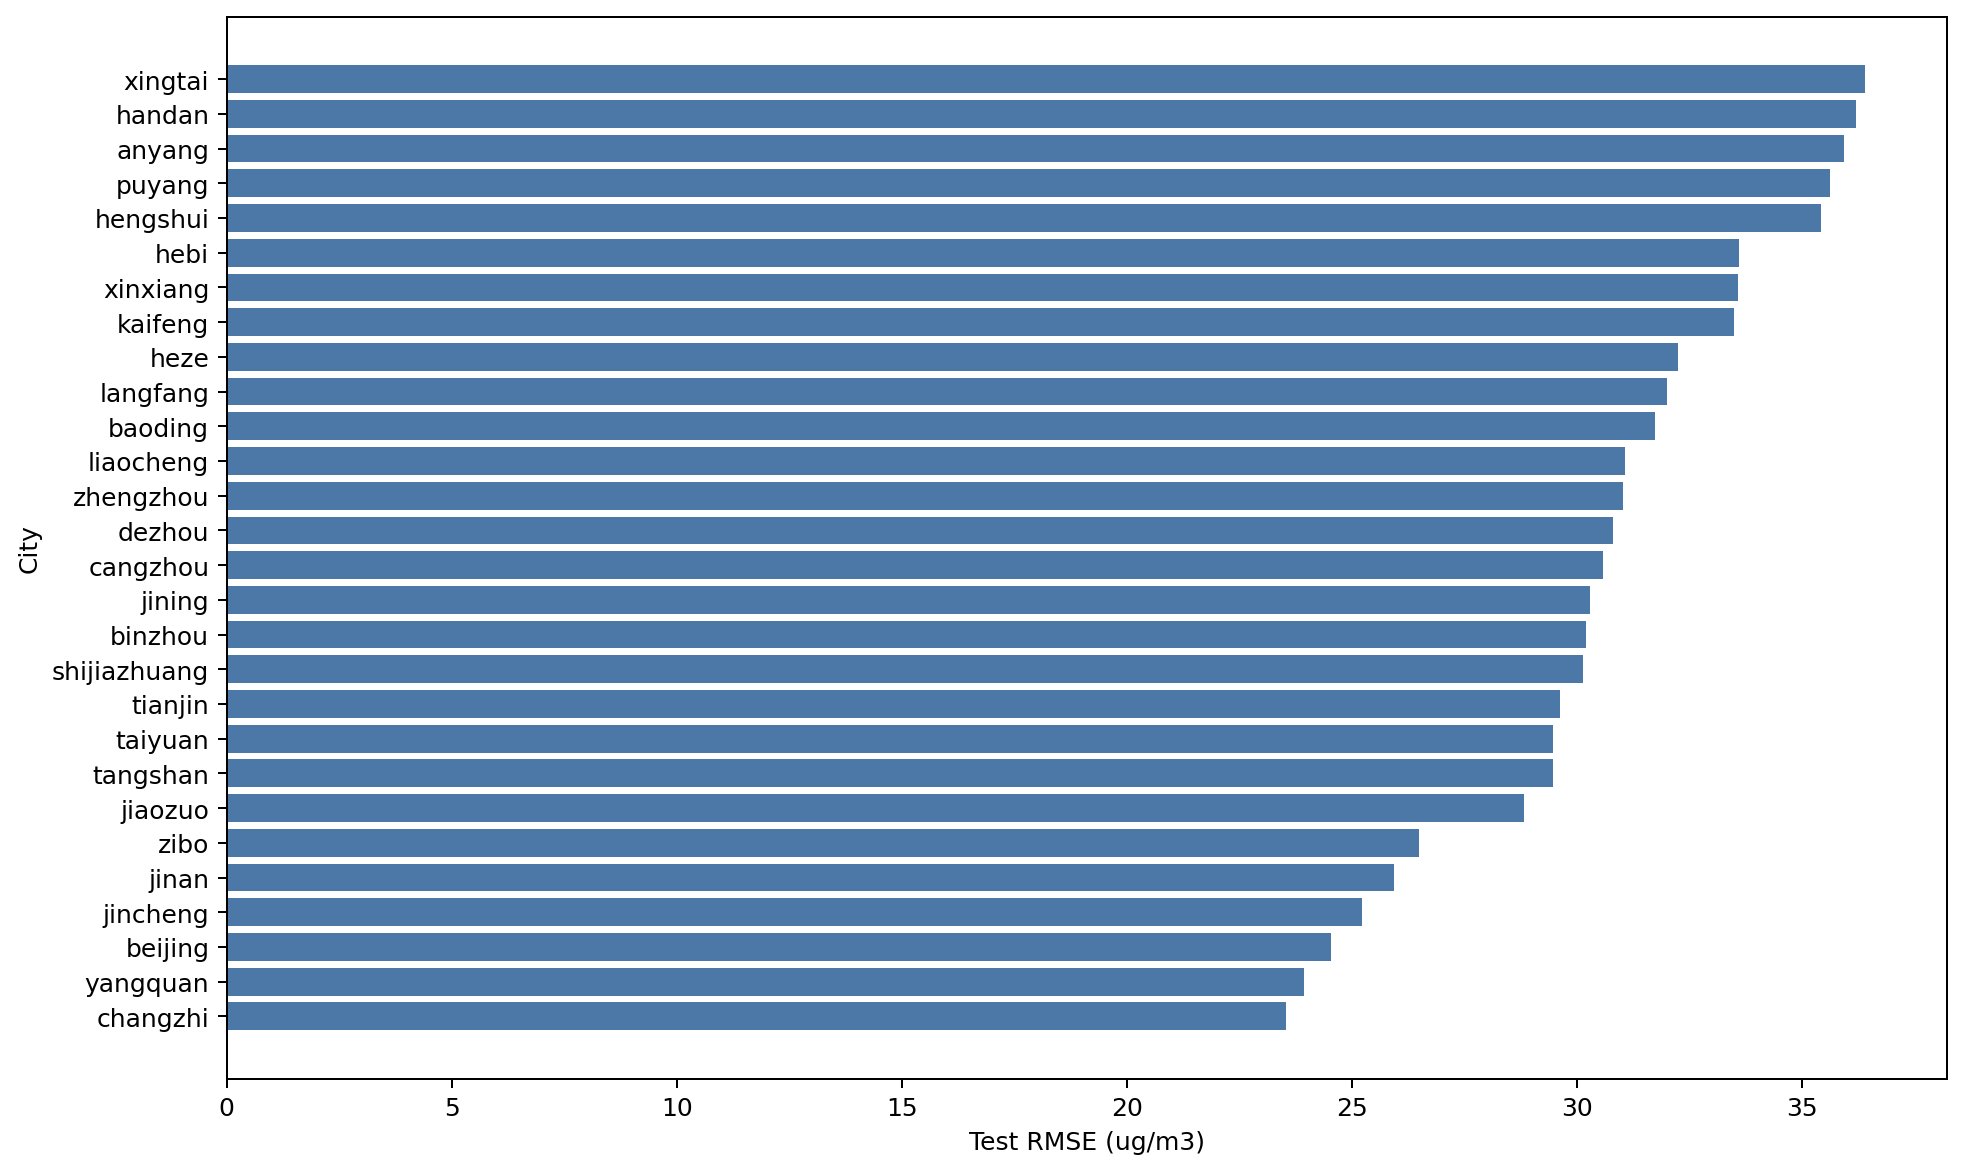

fig/bthsa_pm25_deweather_shap/regional_pm25_deweathered_timeseries.png


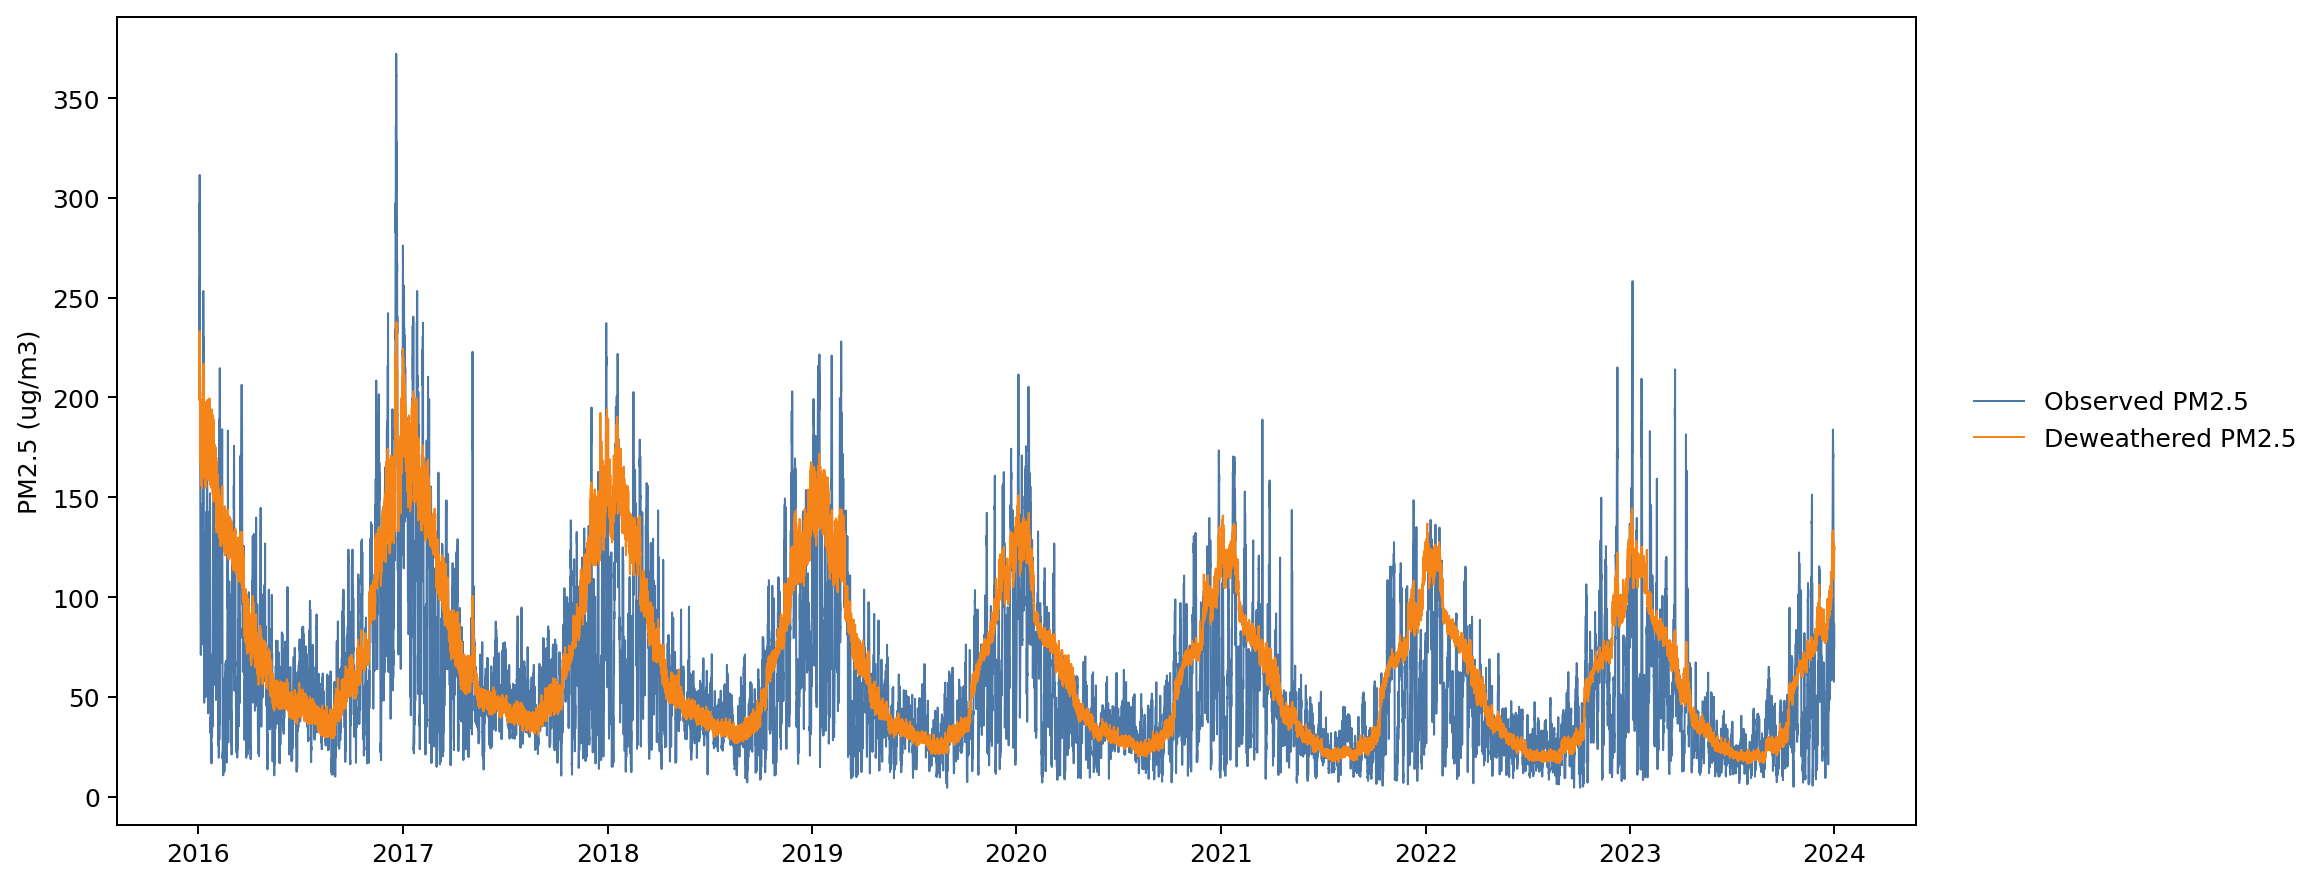

fig/bthsa_pm25_deweather_shap/shap_global_top_features.png


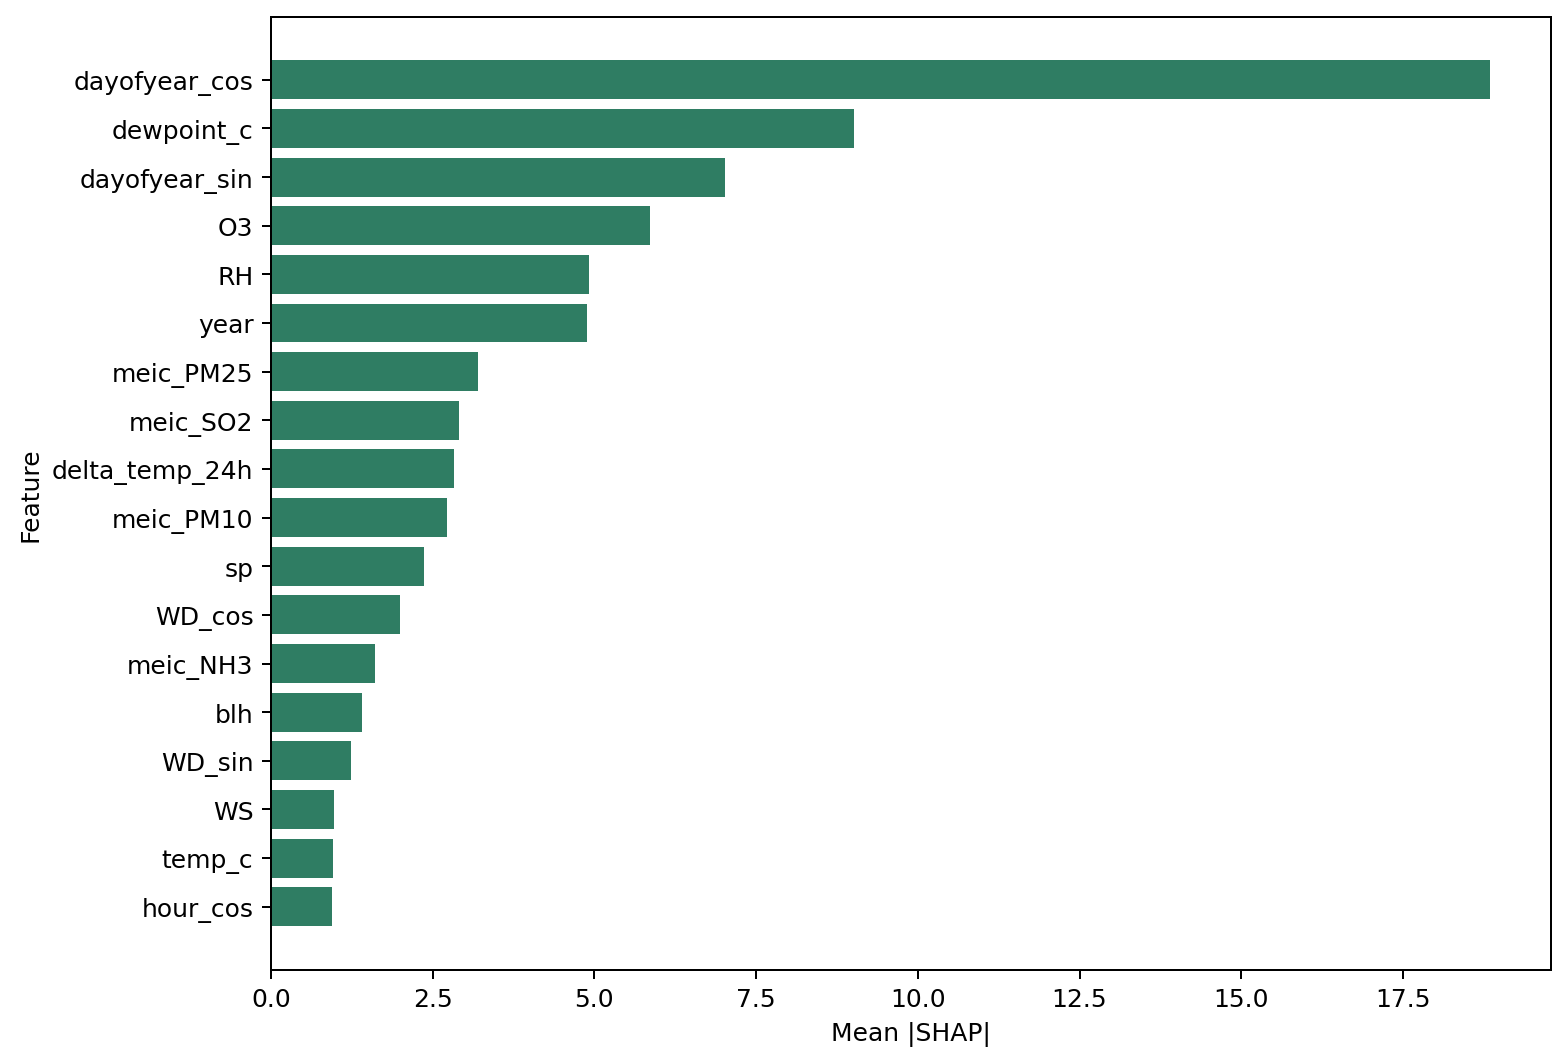

fig/bthsa_pm25_deweather_shap/city_feature_shap_heatmap.png


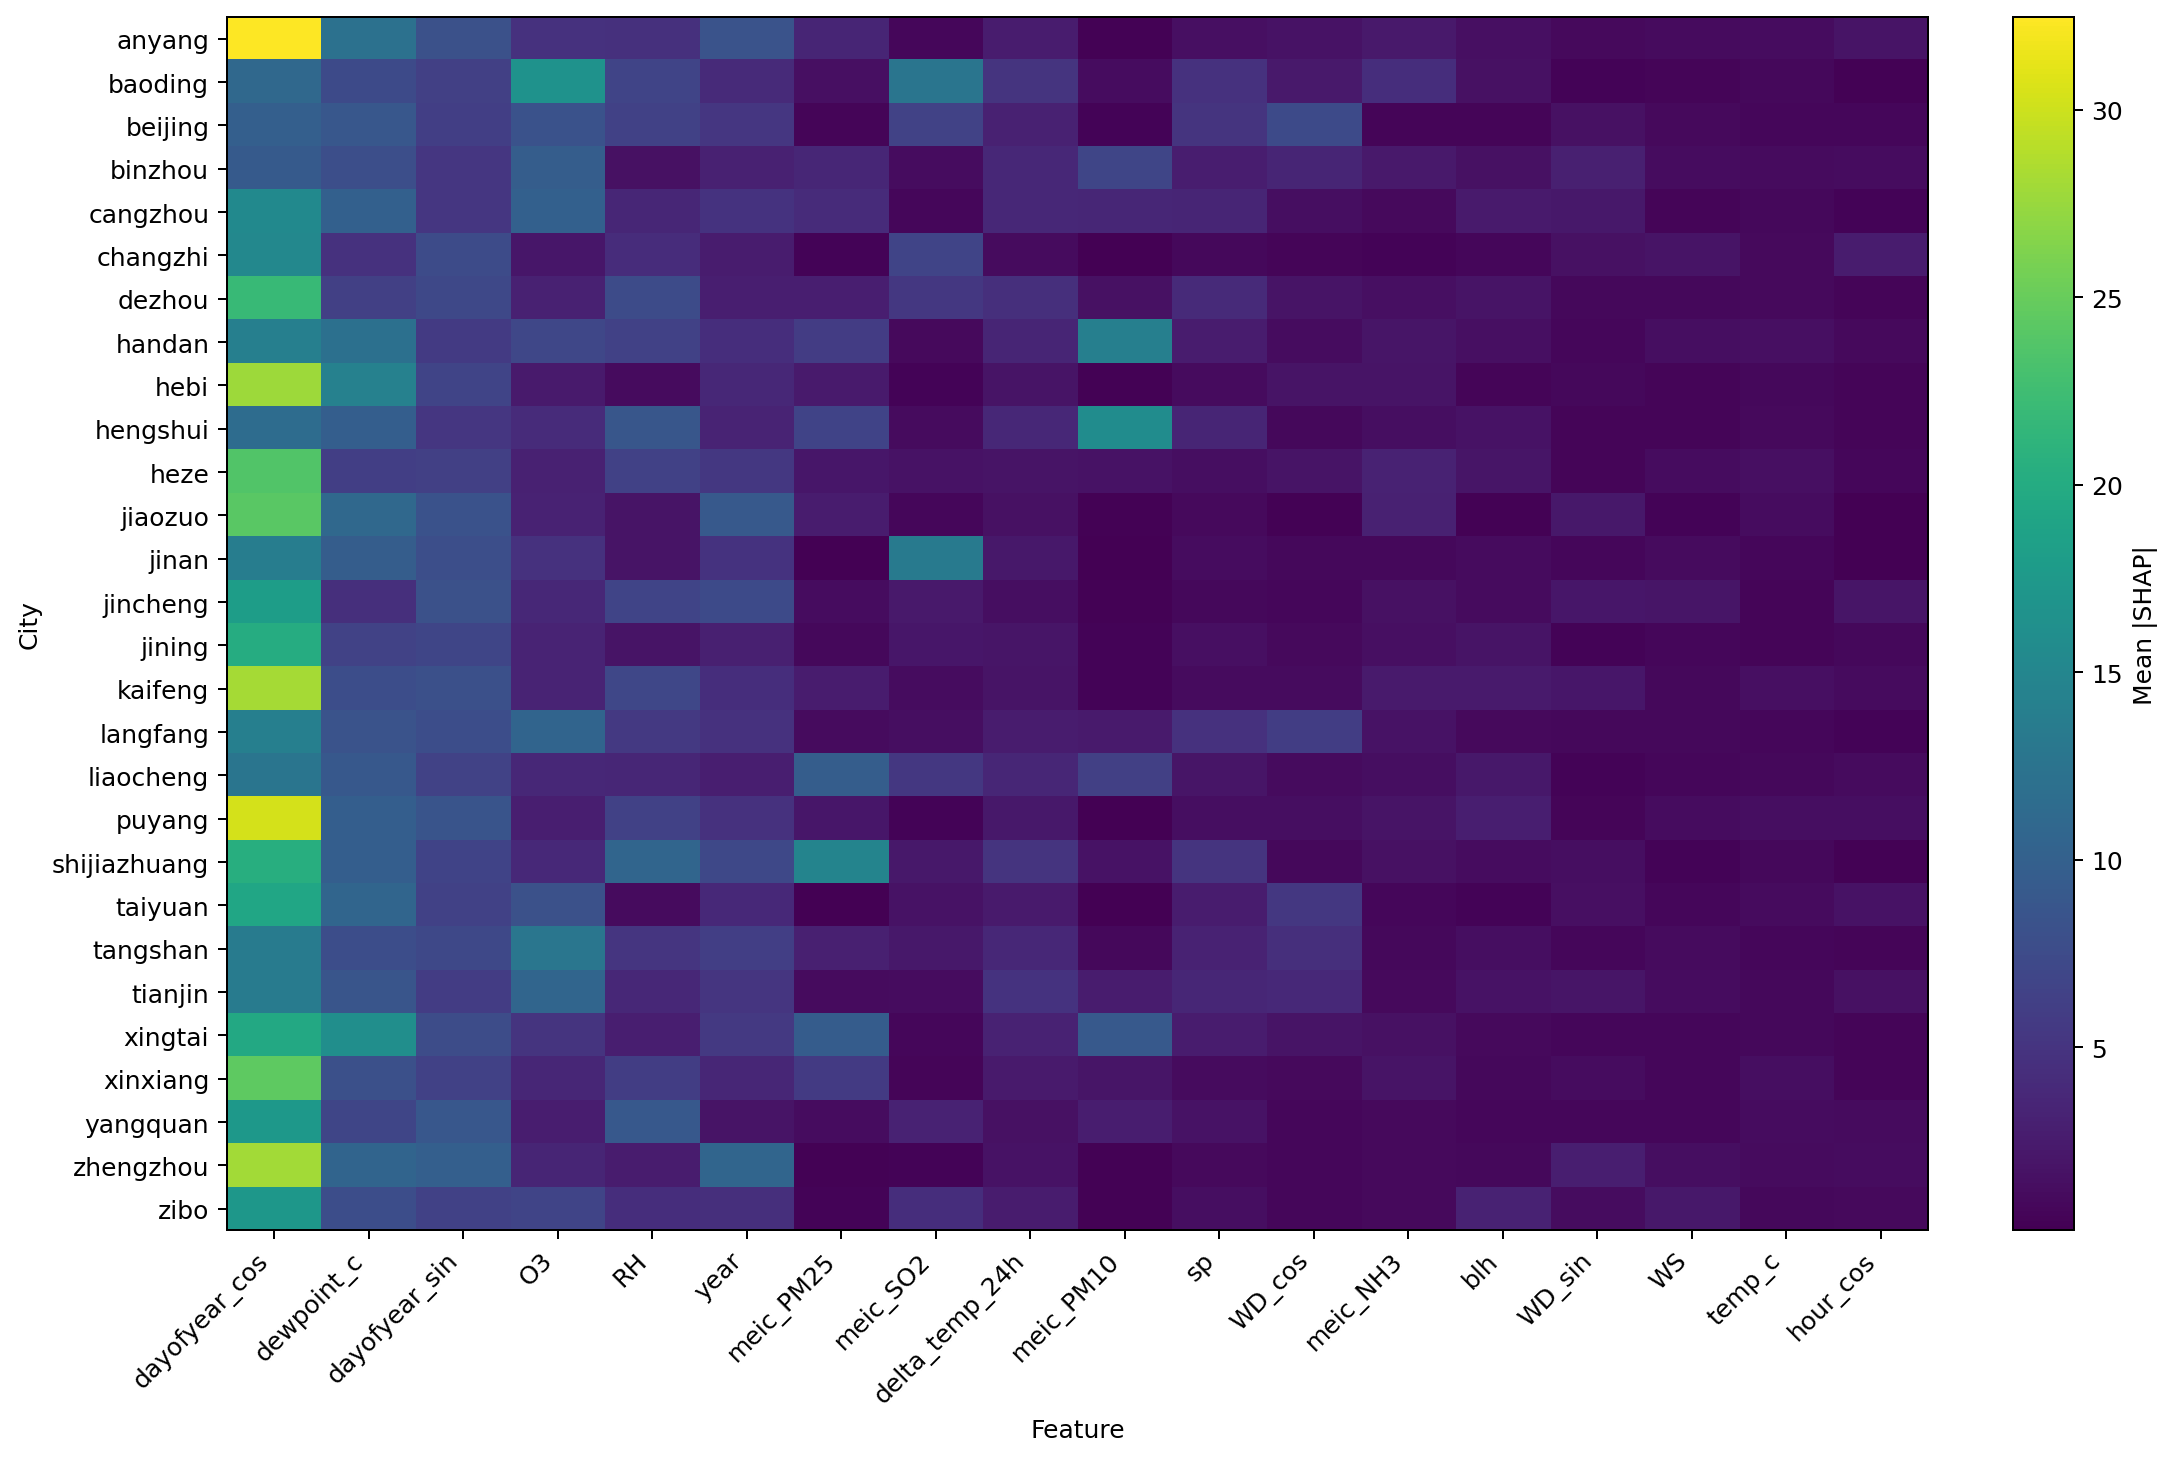

fig/bthsa_pm25_deweather_shap/shap_dependence_RH.png


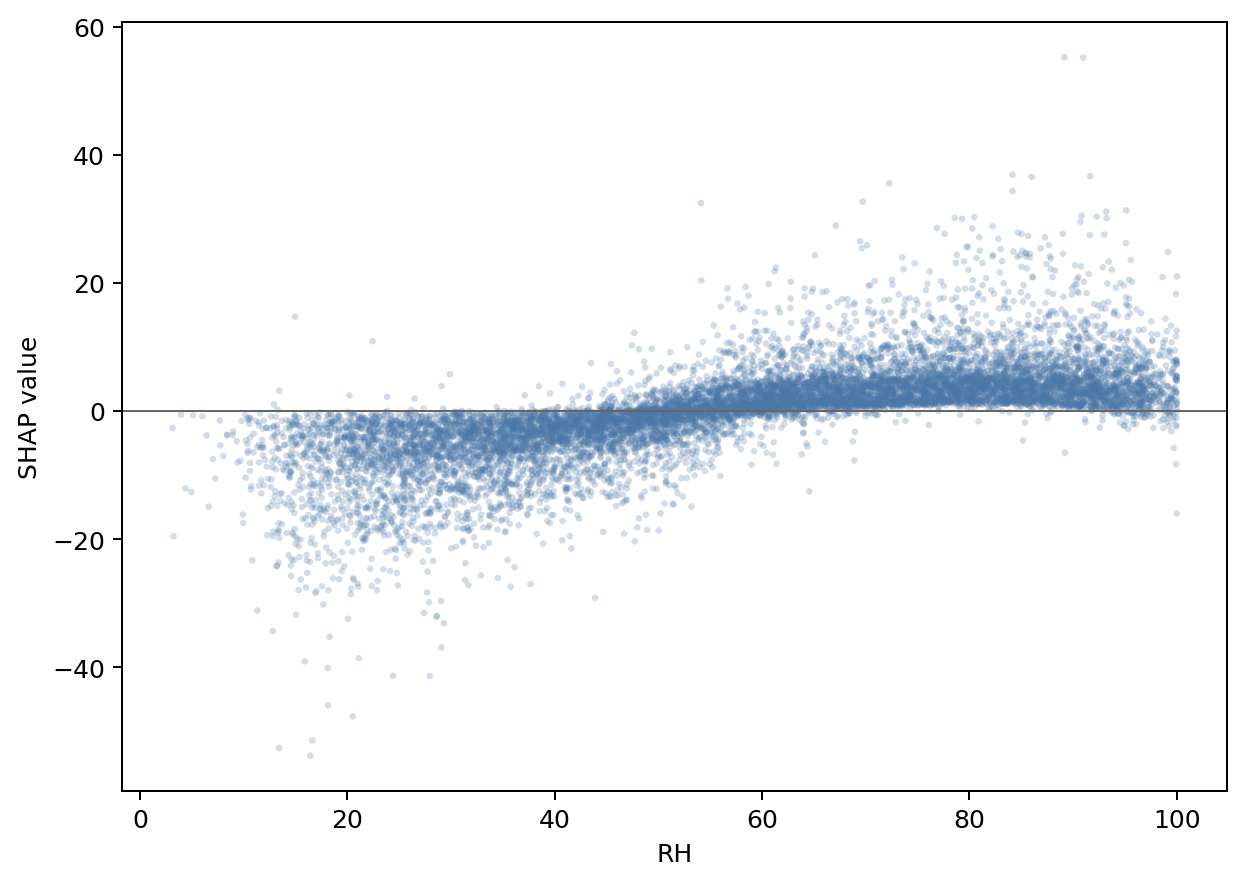

fig/bthsa_pm25_deweather_shap/shap_dependence_temp_c.png


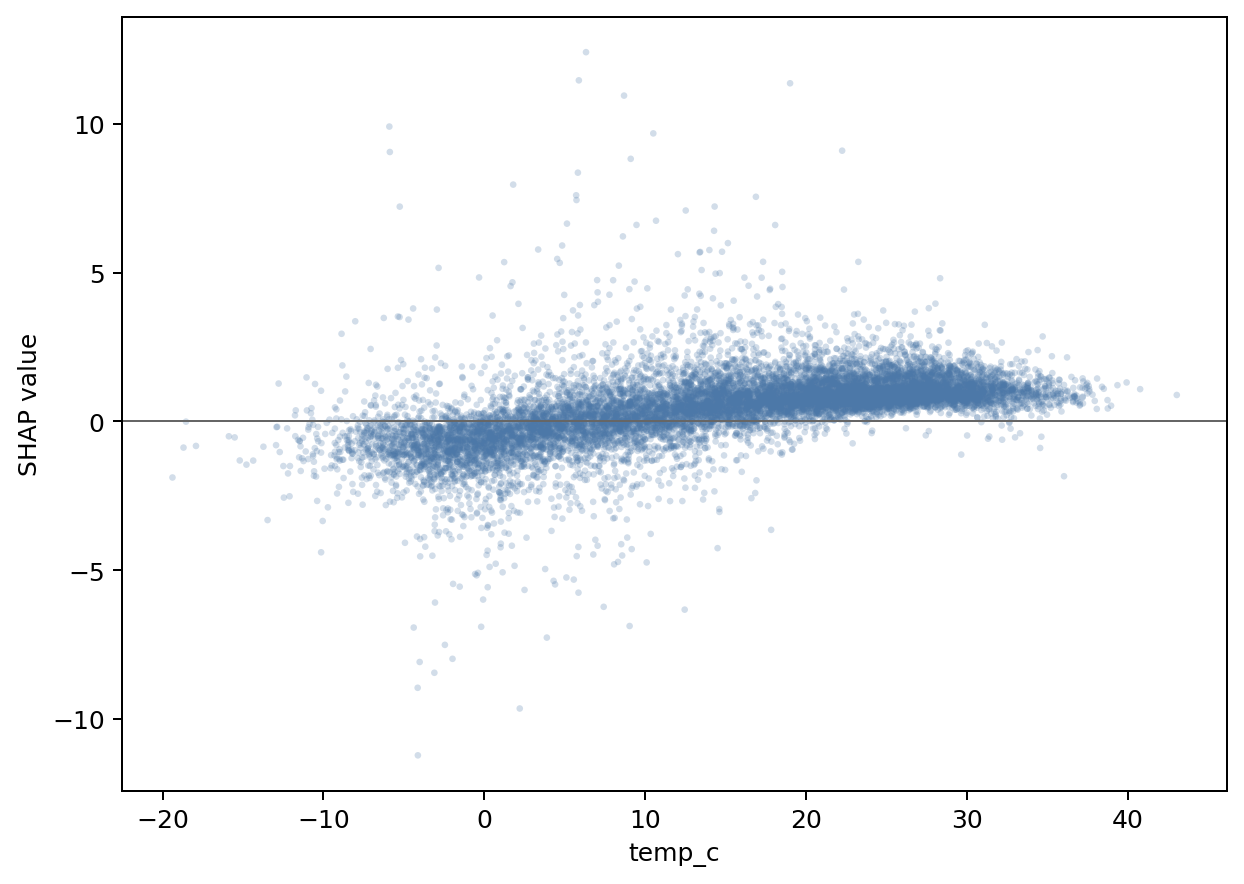

In [21]:
from IPython.display import Image, display

for path in plot_paths[:6]:
    print(path.relative_to(ROOT))
    display(Image(filename=str(path)))

## Artifact Manifest

In [22]:
for artifact in [
    config.resolved_cache_dir / "city_hourly_features.csv",
    config.resolved_cache_dir / "model_metrics.csv",
    config.resolved_cache_dir / "deweathered_pm25.csv",
    config.resolved_cache_dir / "shap_values_sampled.npz",
    config.resolved_cache_dir / "shap_global_importance.csv",
]:
    print(artifact.relative_to(ROOT), artifact.exists(), artifact.stat().st_size if artifact.exists() else None)

for path in plot_paths:
    print(path.relative_to(ROOT), path.exists())

exp/cache/bthsa_pm25_deweather_shap/city_hourly_features.csv True 872756895
exp/cache/bthsa_pm25_deweather_shap/model_metrics.csv True 6285
exp/cache/bthsa_pm25_deweather_shap/deweathered_pm25.csv True 174051143
exp/cache/bthsa_pm25_deweather_shap/shap_values_sampled.npz True 34307212
exp/cache/bthsa_pm25_deweather_shap/shap_global_importance.csv True 45750
fig/bthsa_pm25_deweather_shap/model_performance_rmse.png True
fig/bthsa_pm25_deweather_shap/regional_pm25_deweathered_timeseries.png True
fig/bthsa_pm25_deweather_shap/shap_global_top_features.png True
fig/bthsa_pm25_deweather_shap/city_feature_shap_heatmap.png True
fig/bthsa_pm25_deweather_shap/shap_dependence_RH.png True
fig/bthsa_pm25_deweather_shap/shap_dependence_temp_c.png True
fig/bthsa_pm25_deweather_shap/shap_dependence_blh.png True
fig/bthsa_pm25_deweather_shap/shap_dependence_WS.png True
fig/bthsa_pm25_deweather_shap/shap_dependence_msdwswrf.png True
fig/bthsa_pm25_deweather_shap/shap_dependence_O3.png True
fig/bthsa_pm25